## Model Training: XGBoost and Poisson Regression

In this section, we train two advanced machine learning models to predict the match outcome:
Home Win (H), Draw (D), or Away Win (A)

The models used are: XGBoost Classifier (gradient boosted trees) & Poisson Regression (goals-based statistical model)


## Data Preparation

The dataset is split into training and testing sets based on time:
1. Training set: all seasons before 2024–25
2. Test set: 2024–25 season

This temporal split ensures that the model is trained only on past data and evaluated on future matches, reflecting a realistic prediction setting.

We define:
1. FEATURE_COLS: input features used for prediction
2. NON_FEATURES: identifiers and target variables excluded from training

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from xgboost import XGBClassifier
from sklearn.linear_model import PoissonRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_sample_weight
from scipy.stats import poisson

# Load processed data
df = pd.read_csv("pl_matches_final.csv")
df['Date'] = pd.to_datetime(df['Date'])

# Define features and target
NON_FEATURES = ["Date", "HomeTeam", "AwayTeam", "result", "home_goals", "away_goals", "season", "gameweek", "is_test"]
FEATURE_COLS = [col for col in df.columns if col not in NON_FEATURES]

# Split dataset into training and testing sets
train = df[df["is_test"] == False].copy()
test = df[df["is_test"] == True].copy()

X_train = train[FEATURE_COLS]
y_train = train['result']
X_test = test[FEATURE_COLS]
y_test = test['result']

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Features used: {len(FEATURE_COLS)}")

Training samples: 3420
Test samples: 380
Features used: 27


⸻

## XGBoost Classifier with Hyperparameter Tuning

XGBoost (Extreme Gradient Boosting) is utilized here to capture complex, non-linear relationships in team performance data.

A pipeline-based approach is used with:
	1.	Label Encoding
Converting categorical match results (H, D, A) to numeric codes (0, 1, 2).
	2.	Class Balancing
Utilizing compute_sample_weight to address the inherent class imbalance in football outcomes.
	3.	Randomized Hyperparameter Search
Optimizing n_estimators, max_depth, and learning_rate through 10 iterations of RandomizedSearchCV with 3-fold cross-validation.

The model with the best performance on the cross-validation data is selected for final evaluation.

In [5]:
# Encode target labels
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Handle class imbalance using sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

# Hyperparameter Distribution
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

xgb = XGBClassifier(random_state=42, eval_metric='mlogloss')

xgb_cv = RandomizedSearchCV(xgb, param_distributions=param_dist, n_iter=10, cv=3, scoring='accuracy', random_state=42)
xgb_cv.fit(X_train, y_train_encoded, sample_weight=sample_weights)

best_xgb = xgb_cv.best_estimator_
print(f"Best Parameters: {xgb_cv.best_params_}")
print(f"Best CV Score: {xgb_cv.best_score_:.4f}")

y_pred_xgb_num = best_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_num)
y_prob_xgb = best_xgb.predict_proba(X_test)

print(f"XGBoost Test Accuracy: {accuracy_score(y_test_encoded, y_pred_xgb_num):.4f}")

Best Parameters: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.01}
Best CV Score: 0.4492
XGBoost Test Accuracy: 0.5053


## Feature Importance (XGBoost)

We extract and evaluate feature importances from the tuned XGBoost model to identify the primary drivers of match results. For transparency, all importance weights are exported to CSV.

Top 10 Feature Importances:


,feature,importance
26,home_away_strength_diff,0.107842
16,away_season_avg_scored,0.083413
14,home_season_avg_scored,0.077194
2,home_rolling5_shots,0.045293
19,home_league_position,0.044724
3,home_rolling5_shots_on_target,0.041430
7,away_rolling5_shots,0.039092
23,h2h_avg_total_goals,0.033593
0,home_rolling5_goals_scored,0.032474
15,home_season_avg_conceded,0.031688


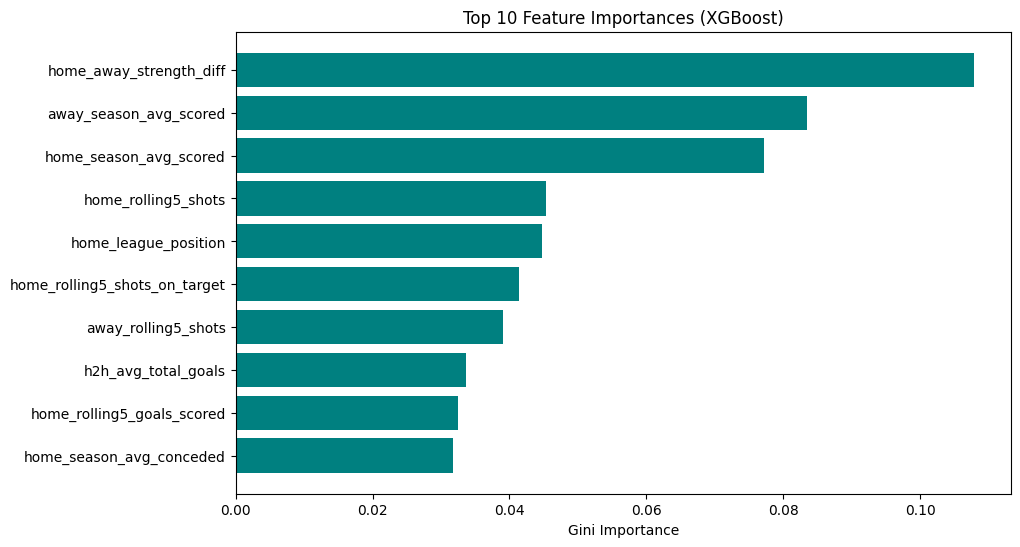

XGBoost Feature Importances exported to project directory.


In [ ]:
# Feature importance
importances = best_xgb.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Top 10 Features (table and plot)
print("Top 10 Feature Importances:")
display(feature_importance_df.head(10))

plt.figure(figsize=(10, 6))
top_10 = feature_importance_df.head(10)
plt.barh(top_10['feature'][::-1], top_10['importance'][::-1], color='teal')
plt.title("Top 10 Feature Importances (XGBoost)")
plt.xlabel("Gini Importance")
plt.show()

# Create CSV file
feature_importance_df.to_csv("xgb_feature_importances.csv", index=False)

## Poisson Regression

Poisson regression models the process of scoring goals as a discrete rate. We model Home and Away goal intensities independently.

The implementation involves:
	1.	Independent Goal Pipelines
Separate pipelines utilizing median imputation and standard scaling followed by a PoissonRegressor.
	2.	Probability Matrix Derivation
Calculating a 10x10 joint probability matrix for all match scorelines.
	3.	Match Outcome Summation
Deriving definitive win, draw, and loss probabilities.

In [7]:
# Target variables for Poisson (2 models)
y_train_h = train['home_goals']
y_train_a = train['away_goals']

# Create Pipelines with Scaling
poisson_h = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()), 
    ('model', PoissonRegressor(max_iter=1000))
])
poisson_a = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('scaler', StandardScaler()), 
    ('model', PoissonRegressor(max_iter=1000))
])

poisson_h.fit(X_train, y_train_h)
poisson_a.fit(X_train, y_train_a)

# Predict expected goals (lambdas)
exp_h = poisson_h.predict(X_test)
exp_a = poisson_a.predict(X_test)

# Function to derive match probabilities (H/D/A) from expected goals
def calculate_match_probs(mu_h, mu_a, max_goals=10):
    prob_matrix = np.outer(poisson.pmf(np.arange(max_goals + 1), mu_h), 
                           poisson.pmf(np.arange(max_goals + 1), mu_a))
    
    prob_h = np.sum(np.tril(prob_matrix, -1))
    prob_d = np.sum(np.diag(prob_matrix))
    prob_a = np.sum(np.triu(prob_matrix, 1))
    
    total = prob_h + prob_d + prob_a
    return prob_h/total, prob_d/total, prob_a/total

poisson_probs = [calculate_match_probs(h, a) for h, a in zip(exp_h, exp_a)]
p_h, p_d, p_a = zip(*poisson_probs)

result_map = {0: 'H', 1: 'D', 2: 'A'}
y_pred_poisson = [result_map[np.argmax([h, d, a])] for h, d, a in poisson_probs]

print(f"Poisson Test Accuracy: {accuracy_score(y_test, y_pred_poisson):.4f}")

Poisson Test Accuracy: 0.5289


## Feature Importance (Poisson)

Extracting model coefficients from the independent Poisson models to identify feature influence on goal rates.

In [ ]:
# Home and Away model features
coef_h = poisson_h.named_steps['model'].coef_
coef_a = poisson_a.named_steps['model'].coef_

poisson_importances = pd.DataFrame({
    'feature': FEATURE_COLS,
    'coef_home': coef_h,
    'coef_away': coef_a
}).sort_values(by='coef_home', ascending=False)

display(poisson_importances.head(10))

# Create CSV file
poisson_importances.to_csv("poisson_feature_importances.csv", index=False)

,feature,coef_home,coef_away
14,home_season_avg_scored,0.045706,-0.022946
2,home_rolling5_shots,0.042173,-0.027340
3,home_rolling5_shots_on_target,0.031875,-0.023718
17,away_season_avg_conceded,0.030941,-0.013021
0,home_rolling5_goals_scored,0.028768,-0.007593
4,home_rolling5_corners,0.028603,-0.004695
11,home_form_goals_scored,0.020283,-0.009387
26,home_away_strength_diff,0.018441,-0.024228
6,away_rolling5_goals_conceded,0.018337,-0.003744
18,home_points,0.017803,-0.022801


Poisson Feature Coefficients exported to project directory.


## Model Evaluation

Both models are evaluated using confusion matrices and accuracy to assess performance across all match categories.

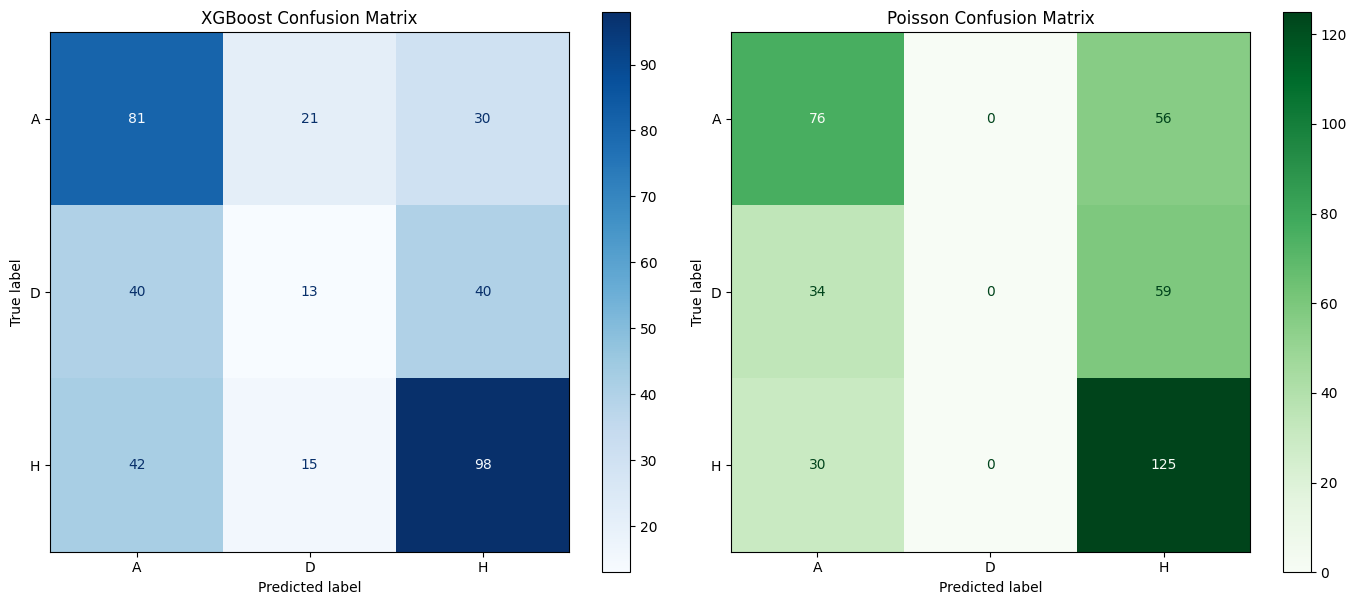

XGBoost Classification Report
              precision    recall  f1-score   support

           A       0.50      0.61      0.55       132
           D       0.27      0.14      0.18        93
           H       0.58      0.63      0.61       155

    accuracy                           0.51       380
   macro avg       0.45      0.46      0.45       380
weighted avg       0.48      0.51      0.48       380

Poisson Classification Report
              precision    recall  f1-score   support

           A       0.54      0.58      0.56       132
           D       0.00      0.00      0.00        93
           H       0.52      0.81      0.63       155

    accuracy                           0.53       380
   macro avg       0.35      0.46      0.40       380
weighted avg       0.40      0.53      0.45       380



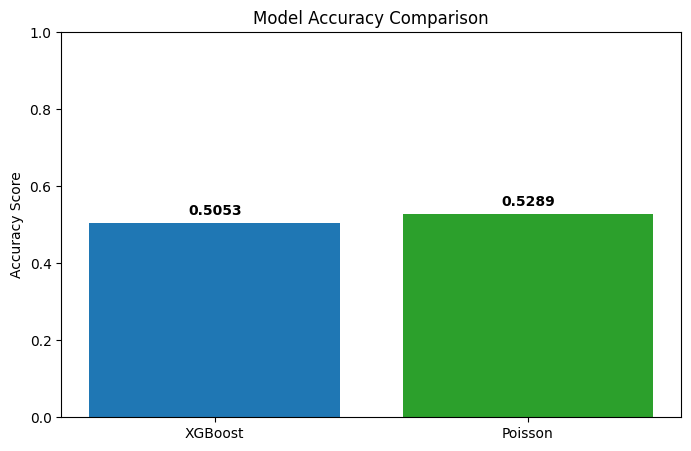

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb, ax=ax[0], cmap='Blues')
ax[0].set_title("XGBoost Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_poisson, ax=ax[1], cmap='Greens')
ax[1].set_title("Poisson Confusion Matrix")

plt.tight_layout()
plt.show()

print("XGBoost Classification Report")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

print("Poisson Classification Report")
print(classification_report(y_test, y_pred_poisson, zero_division=0))

# Accuracy Comparison
model_names = ["XGBoost", "Poisson"]
accuracies = [accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_poisson)]

plt.figure(figsize=(8, 5))
plt.bar(model_names, accuracies, color=['#1f77b4', '#2ca02c'])
plt.ylim(0, 1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy Score")
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

## Predictions and Probabilities

Generating final prediction files for both models; including calculated probabilities for Home Win, Draw, and Away Win.

In [10]:

# Save XGBoost Predictions to CSV file
preds_xgb = pd.DataFrame({
    'Date': test['Date'],
    'HomeTeam': test['HomeTeam'],
    'AwayTeam': test['AwayTeam'],
    'y_true': y_test,
    'y_pred': y_pred_xgb,
    'prob_H': y_prob_xgb[:, le.transform(['H'])[0]],
    'prob_D': y_prob_xgb[:, le.transform(['D'])[0]],
    'prob_A': y_prob_xgb[:, le.transform(['A'])[0]]
})
preds_xgb.to_csv("preds_xgb.csv", index=False)


# Save Poisson Predictions to CSV file
preds_poisson = pd.DataFrame({
    'Date': test['Date'],
    'HomeTeam': test['HomeTeam'],
    'AwayTeam': test['AwayTeam'],
    'y_true': y_test,
    'y_pred': y_pred_poisson,
    'prob_H': p_h,
    'prob_D': p_d,
    'prob_A': p_a
})
preds_poisson.to_csv("preds_poisson.csv", index=False)
